# LASSO Feature Selection
### HBV-Related Hepatocellular Carcinoma (HBV-HCC) Early Detection
---
This notebook reduces the 2,245 DEG features down to only the genes
that are most predictive of HCC tumor vs non-tumor classification.

**Steps:**
1. Load `X_features.csv` and `y_labels.csv`
2. Standardize features using StandardScaler
3. Run LassoCV to find the optimal penalty parameter
4. Extract genes with non-zero coefficients
5. Save reduced feature matrix as `X_lasso.csv`

**Input:** `data/X_features.csv`, `data/y_labels.csv`  
**Output:** `data/X_lasso.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, roc_curve)
from xgboost import XGBClassifier

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 1: Load Feature Matrix and Labels

In [2]:
# Load features and labels
X = pd.read_csv('../data/X_features.csv', index_col=0)
y = pd.read_csv('../data/y_labels.csv', index_col=0)

# Flatten y to a 1D array
y = y.squeeze()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nLabel distribution:\n{y.value_counts()}")

X shape: (468, 2245)
y shape: (468,)

Label distribution:
label
0    239
1    229
Name: count, dtype: int64


## Step 2: Standardize Features
LASSO is sensitive to the scale of input features. We apply StandardScaler
to ensure all genes are on the same scale before running LassoCV.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaling complete.")
print(f"Mean (should be ~0): {X_scaled.mean():.4f}")
print(f"Std  (should be ~1): {X_scaled.std():.4f}")

Scaling complete.
Mean (should be ~0): -0.0000
Std  (should be ~1): 1.0000


## Step 3: LASSO Feature Selection
LassoCV automatically finds the optimal regularization parameter (alpha)
using cross-validation. Genes with non-zero coefficients after fitting
are selected as the most predictive features for HCC classification.

In [5]:
from sklearn.linear_model import LassoCV

# Run LassoCV with 5-fold cross-validation
lasso = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso.fit(X_scaled, y)

# Extract selected features (non-zero coefficients)
selected_mask = lasso.coef_ != 0
selected_genes = X.columns[selected_mask]

print(f"Optimal alpha (penalty): {lasso.alpha_:.6f}")
print(f"Total features before LASSO: {X.shape[1]}")
print(f"Features selected by LASSO: {len(selected_genes)}")

Optimal alpha (penalty): 0.012773
Total features before LASSO: 2245
Features selected by LASSO: 71


## Step 4: Save Selected Features
We reduce the feature matrix to only the 71 LASSO-selected genes
and save it as X_lasso.csv for use in model training.

In [6]:
# Reduce X to selected features only
X_lasso = X[selected_genes]

print(f"Reduced feature matrix shape: {X_lasso.shape}")

# Save to data folder
X_lasso.to_csv('../data/X_lasso.csv')

print("X_lasso.csv saved successfully!")

Reduced feature matrix shape: (468, 71)
X_lasso.csv saved successfully!


## Step 5: Visualize LASSO Coefficients
The magnitude of each coefficient reflects how strongly that gene
contributes to the prediction. Larger absolute value = stronger contribution.

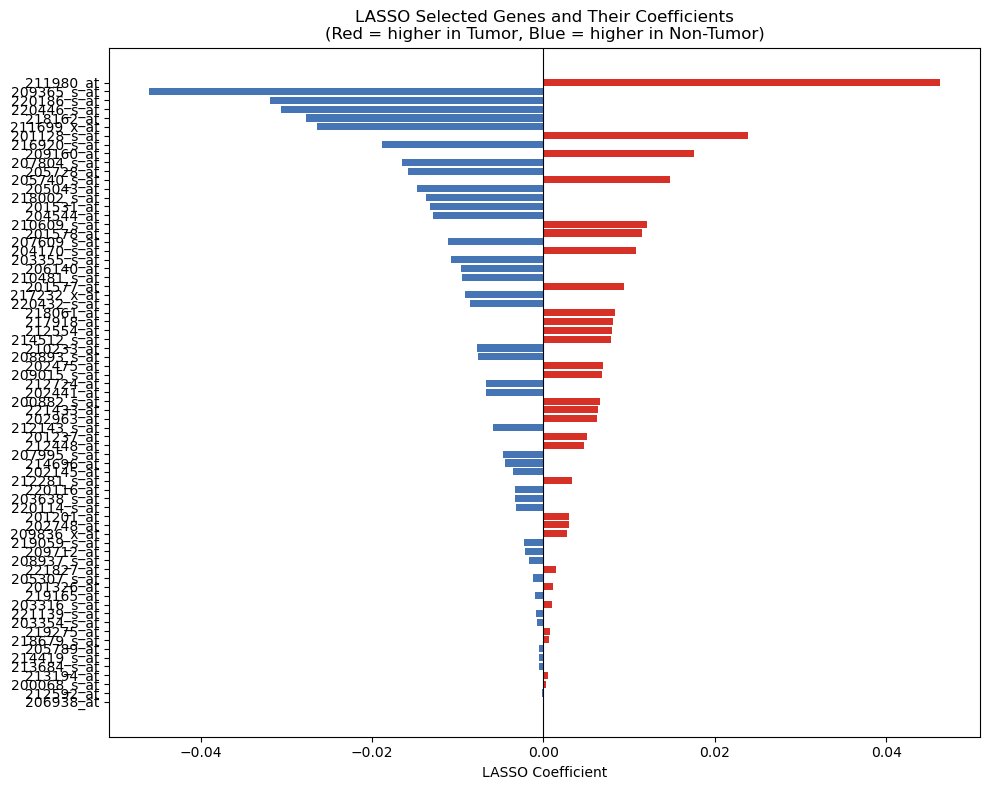

Plot saved to results/lasso_coefficients.png


In [7]:
# Plot LASSO coefficients for selected genes
coef_series = pd.Series(lasso.coef_[selected_mask], index=selected_genes)
coef_series = coef_series.reindex(coef_series.abs().sort_values(ascending=True).index)

plt.figure(figsize=(10, 8))
colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_series.values]
plt.barh(coef_series.index, coef_series.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('LASSO Coefficient')
plt.title('LASSO Selected Genes and Their Coefficients\n(Red = higher in Tumor, Blue = higher in Non-Tumor)')
plt.tight_layout()
plt.savefig('../results/lasso_coefficients.png', dpi=150)
plt.show()
print("Plot saved to results/lasso_coefficients.png")

## Summary

LASSO-based feature selection successfully reduced the dimensionality
of the gene expression dataset from 2,245 DEG features to 71 highly
predictive genes.

| Step | Detail |
|------|--------|
| Input features | 2,245 DEGs (adj.P.Val < 0.05, logFC > 1) |
| Scaling method | StandardScaler (mean=0, std=1) |
| Selection method | LassoCV (5-fold cross-validation) |
| Optimal alpha | 0.012773 |
| Selected features | 71 genes |
| Reduction | 96.8% fewer features |

The 71 selected genes represent the most informative expression
signatures for distinguishing HCC tumor from non-tumor liver tissue.
The reduced feature matrix has been saved to `data/X_lasso.csv`
for use in model training.